# Training RawNet2 for Audio Spoofing Detection

ResNet model adapted from **End-to-end anti-spoofing with RawNet2** ([paper](https://doi.org/10.48550/arXiv.2011.01108), [repo](https://github.com/eurecom-asp/rawnet2-antispoofing/tree/main)). <br>
Training procedure adapted from **Listening Between the Lines: Synthetic Speech Detection Disregarding Verbal Content** ([paper](https://doi.org/10.1109/ICASSPW62465.2024.10669901))

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import random
import numpy as np
import torch
import os

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
set_seed(SEED)

In [4]:
from src.data_utils import ASVDataset, collate_fn_asvspoof
from src.features import log_spectrum_extractor
from src.samplers import BalancedBatchSampler
from src.utils import EarlyStopping
from src.models.rawnet2 import RawNet
from sklearn.metrics import roc_curve, roc_auc_score, balanced_accuracy_score
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

from IPython.display import Audio, display
from torchinfo import summary
from tqdm.auto import tqdm

import soundfile as sf
import librosa
import pandas as pd
import matplotlib.pyplot as plt

/root/reproduction-salvi-et-al/env/lib/python3.10/site-packages/webrtcvad.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Loading LA subset + extracting features
- All audio clips are resized to a length of 2 seconds (32,000 samples)

In [5]:
DATA_PATH = str(Path.cwd().parent / 'data' / 'ASVspoof2019_LA')
PROTOCOLS_PATH = str(Path.cwd().parent / 'data' / 'ASVspoof2019_LA' / 'ASVspoof2019_LA_cm_protocols')
CACHE_DIR = str(Path.cwd().parent / 'data_caches')

FEATURE_NAME = 'raw'
tf = lambda x: torch.tensor(x)

In [6]:
train_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH, 
    is_train=True, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=2.0, pad_to_max=True, transform=tf
)

sysid_dict_inv {0: '-', 1: 'A01', 2: 'A02', 3: 'A03', 4: 'A04', 5: 'A05', 6: 'A06'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name train
protocols_fname train.trn
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_train/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_train_LA_raw_2.0s_pad.npy
mask_cache_fname /root/reproduction-salvi-et-al/data_caches/cache_train_LA_raw_2.0s_pad.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_train_LA_raw_2.0s_pad.npy
Dataset loaded from cache successfully


In [7]:
dev_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH, 
    is_train=False, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=2.0, pad_to_max=True, transform=tf
)

sysid_dict_inv {0: '-', 1: 'A01', 2: 'A02', 3: 'A03', 4: 'A04', 5: 'A05', 6: 'A06'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name dev
protocols_fname dev.trl
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_dev/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_raw_2.0s_pad.npy
mask_cache_fname /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_raw_2.0s_pad.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_raw_2.0s_pad.npy
Dataset loaded from cache successfully


In [8]:
eval_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH,
    is_eval=True, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=2.0, pad_to_max=True, transform=tf
)

sysid_dict_inv {0: '-', 1: 'A07', 2: 'A08', 3: 'A09', 4: 'A10', 5: 'A11', 6: 'A12', 7: 'A13', 8: 'A14', 9: 'A15', 10: 'A16', 11: 'A17', 12: 'A18', 13: 'A19'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name eval
protocols_fname eval.trl
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_eval/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_raw_2.0s_pad.npy
mask_cache_fname /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_raw_2.0s_pad.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_raw_2.0s_pad.npy
Dataset loaded from cache successfully


In [9]:
demo_indices = [0, 3000, 3000 + 3800 * 2, 3000 + 3800 * 4]
demos = []

for idx, sample_idx in enumerate(demo_indices):
    D, label, meta = train_data[sample_idx]
    demos.append((D.numpy(), label, meta))

In [10]:
for audio, label, meta in demos:
    print(f"\n{'Bonafide' if label == 1.0 else 'Spoof'} - {meta.file_name}")
    print(f"System: {train_data.sysid_dict_inv[meta.sys_id]}")
    display(Audio(audio, rate=16000))


Bonafide - LA_T_1138215
System: -



Spoof - LA_T_3740126
System: A01



Spoof - LA_T_3711779
System: A03



Spoof - LA_T_3285771
System: A05


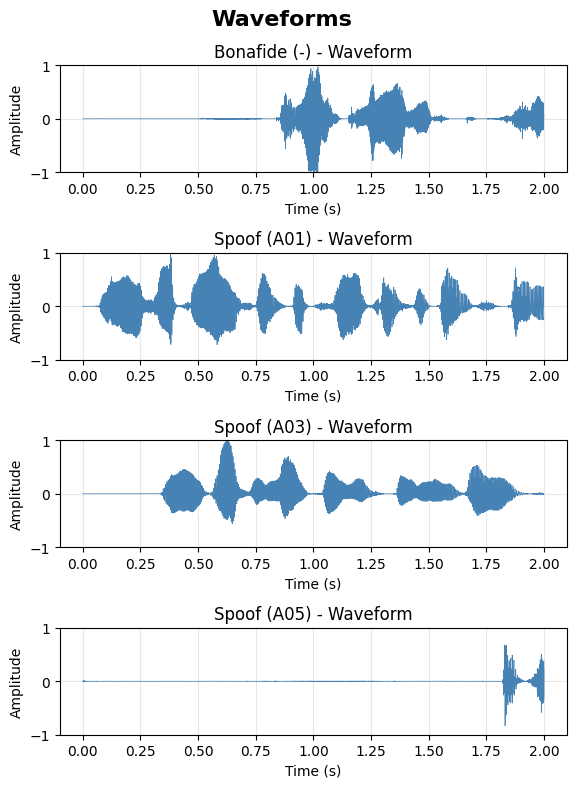

In [11]:
fig, axes = plt.subplots(len(demo_indices), 1, figsize=(6, 2*len(demo_indices)))

for idx, (audio, label, meta) in enumerate(demos):
    sys_name = train_data.sysid_dict_inv[meta.sys_id]
    label_name = 'Bonafide' if label == 1.0 else 'Spoof'
    
    # Waveform
    ax_wave = axes[idx]
    time = np.arange(len(audio)) / 16000
    ax_wave.plot(time, audio, linewidth=0.5, color='steelblue')
    ax_wave.set_title(f'{label_name} ({sys_name}) - Waveform')
    ax_wave.set_xlabel('Time (s)')
    ax_wave.set_ylabel('Amplitude')
    ax_wave.set_ylim(-1, 1)
    ax_wave.grid(alpha=0.3)

fig.suptitle('Waveforms', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Model

In [12]:
model_config = {
    'margin': 2,
    'nb_samp': 32000,
    'first_conv': 128,
    'in_channels': 1,
    'filts': [128, [128, 128], [128, 512], [512, 512]],
    'blocks': [2, 4],
    'nb_fc_node': 1024,
    'gru_node': 1024,
    'nb_gru_layer': 3,
    'nb_classes': 2
}

device = 'cuda:1' if torch.cuda.is_available() else 'cpu'

In [13]:
model = RawNet(model_config, device)

In [14]:
summary(
    model, 
    input_size=(128, 32000),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: []

## Training

In [15]:
MODEL_SAVE_DIR = Path.cwd().parent / 'models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
WEIGHTS_FNAME = 'rawnet_final.pth'
CHECKPOINT_PATH = MODEL_SAVE_DIR / WEIGHTS_FNAME

BATCH_SIZE = 128
NUM_EPOCHS = 150
LEARNING_RATE = 0.0001
PATIENCE = 20

DEVICE = 'cuda:1' if torch.cuda.is_available() else 'cpu'

print(f"Device: {DEVICE}")

Device: cuda:1


In [16]:
train_labels = [int(l) for l in train_data.data_y]
bonafide_count = sum(1 for l in train_labels if l == 1)
spoof_count = len(train_labels) - bonafide_count
print(f"\nTrain class distribution:")
print(f"Bonafide: {bonafide_count} ({bonafide_count/len(train_labels)*100:.1f}%)")
print(f"Spoof: {spoof_count} ({spoof_count/len(train_labels)*100:.1f}%)")

train_sampler = BalancedBatchSampler(
    labels=train_labels,
    batch_size=BATCH_SIZE,
    seed=SEED,
    drop_last=False
)
    
train_loader = DataLoader(
    train_data,
    batch_sampler=train_sampler,
    collate_fn=collate_fn_asvspoof,
    num_workers=8,
    persistent_workers=True,
    prefetch_factor=2,
    pin_memory=True
)

dev_loader = DataLoader(
    dev_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_asvspoof,
    pin_memory=True
)

eval_loader = DataLoader(
    eval_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_asvspoof,
    pin_memory=True
)

print(f"\nDataLoader batches per epoch:")
print(f"Train: {len(train_loader)}")
print(f"Dev: {len(dev_loader)}")
print(f"Eval: {len(eval_loader)}")


Train class distribution:
Bonafide: 2580 (10.2%)
Spoof: 22800 (89.8%)
BalancedBatchSampler (no majority repeats):
  Bonafide: 2,580
  Spoof:    22,800
  Batch size: 128 (64 per class)
  drop_last: False
  Batches/epoch: 357 (full=356, remainder=16)
  Minority repeats (approx): ~9x
  Last batch will be size 32 (balanced)

DataLoader batches per epoch:
Train: 357
Dev: 195
Eval: 557


In [17]:
model.to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
optimizer = optim.Adam(
    model.parameters(), 
    lr=LEARNING_RATE
)
early_stopping = EarlyStopping(patience=PATIENCE, min_delta=0.0, mode="min")

In [18]:
def train_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    if hasattr(loader, 'batch_sampler') and hasattr(loader.batch_sampler, 'set_epoch'):
        loader.batch_sampler.set_epoch(epoch)
    
    pbar = tqdm(loader, desc=f"Epoch {epoch+1} [Train]")
    for batch_idx, (features, labels, _) in enumerate(pbar):
        features = features.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({
            'loss': running_loss / (batch_idx + 1),
            'acc': 100. * correct / total
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [19]:
def evaluate(model, loader, criterion, device, partition_name='Dev'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_probs = []
    all_predictions = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc=f"{partition_name}")
        for features, labels, _ in pbar:
            features = features.to(device)
            labels = labels.to(device)
            
            logits = model(features)
            loss = criterion(logits, labels)
            
            probs = torch.nn.functional.softmax(logits, dim=1)[:, 1]
            
            running_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            
            pbar.set_postfix({
                'loss': running_loss / (pbar.n + 1),
                'acc': 100. * correct / total
            })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_predictions = np.array(all_predictions)
    
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=1)
    fnr = 1 - tpr
    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
    
    auc = roc_auc_score(all_labels, all_probs)
    
    balanced_acc = balanced_accuracy_score(all_labels, all_predictions) * 100
    
    return epoch_loss, epoch_acc, eer, auc, balanced_acc, all_labels, all_probs

In [20]:
history = {
    'train_loss': [],
    'train_acc': [],
    'dev_loss': [],
    'dev_acc': [],
    'dev_eer': [],
    'dev_auc': [],
    'dev_balanced_acc': [],
    'lr': []
}

best_eer = float('inf')
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE, epoch
    )
    
    dev_loss, dev_acc, dev_eer, dev_auc, dev_balanced_acc, _, _ = evaluate(
        model, dev_loader, criterion, DEVICE, partition_name='Dev'
    )
    
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['dev_loss'].append(dev_loss)
    history['dev_acc'].append(dev_acc)
    history['dev_eer'].append(dev_eer)
    history['dev_auc'].append(dev_auc)
    history['dev_balanced_acc'].append(dev_balanced_acc)
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Dev Loss:   {dev_loss:.4f} | Dev Acc:   {dev_acc:.2f}%")
    print(f"Dev EER:    {dev_eer:.4f} | Dev AUC:   {dev_auc:.4f}")
    print(f"Dev Balanced Acc: {dev_balanced_acc:.2f}%")
    print(f"LR: {current_lr:.6f}")
    
    if dev_eer < best_eer:
        best_eer = dev_eer
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'dev_eer': dev_eer,
            'dev_loss': dev_loss,
            'dev_auc': dev_auc,
            'dev_balanced_acc': dev_balanced_acc,
            'early_stopping': early_stopping.state_dict()
        }, CHECKPOINT_PATH)
        print(f"Saved best model (EER: {dev_eer:.4f})")
    
    if early_stopping(dev_eer, epoch):
        print(f"Early stopping triggered at epoch {epoch+1}")
        print(f"Best epoch: {early_stopping.best_epoch + 1}")
        print(f"Best dev loss: {early_stopping.best_score:.4f}")
        break

print("Training completed")
print(f"Best Dev EER: {best_eer:.4f} at epoch {best_epoch}")

Epoch 1/150


Epoch 1 [Train]:   0%|          | 0/357 [00:01<?, ?it/s]

Dev:   0%|          | 0/195 [00:00<?, ?it/s]

Train Loss: 0.3796 | Train Acc: 95.15%
Dev Loss:   0.3608 | Dev Acc:   96.37%
Dev EER:    0.0514 | Dev AUC:   0.9804
Dev Balanced Acc: 93.51%
LR: 0.000100
Saved best model (EER: 0.0514)
Epoch 2/150


Epoch 2 [Train]:   0%|          | 0/357 [00:00<?, ?it/s]

...

Dev:   0%|          | 0/195 [00:00<?, ?it/s]

Train Loss: 0.3252 | Train Acc: 100.00%
Dev Loss:   0.3568 | Dev Acc:   98.02%
Dev EER:    0.0677 | Dev AUC:   0.9547
Dev Balanced Acc: 90.53%
LR: 0.000100
Epoch 26/150


Epoch 26 [Train]:   0%|          | 0/357 [00:00<?, ?it/s]

Dev:   0%|          | 0/195 [00:00<?, ?it/s]

Train Loss: 0.3251 | Train Acc: 100.00%
Dev Loss:   0.3534 | Dev Acc:   98.24%
Dev EER:    0.0601 | Dev AUC:   0.9604
Dev Balanced Acc: 91.56%
LR: 0.000100
Early stopping triggered at epoch 26
Best epoch: 6
Best dev loss: 0.0283
Training completed
Best Dev EER: 0.0283 at epoch 6


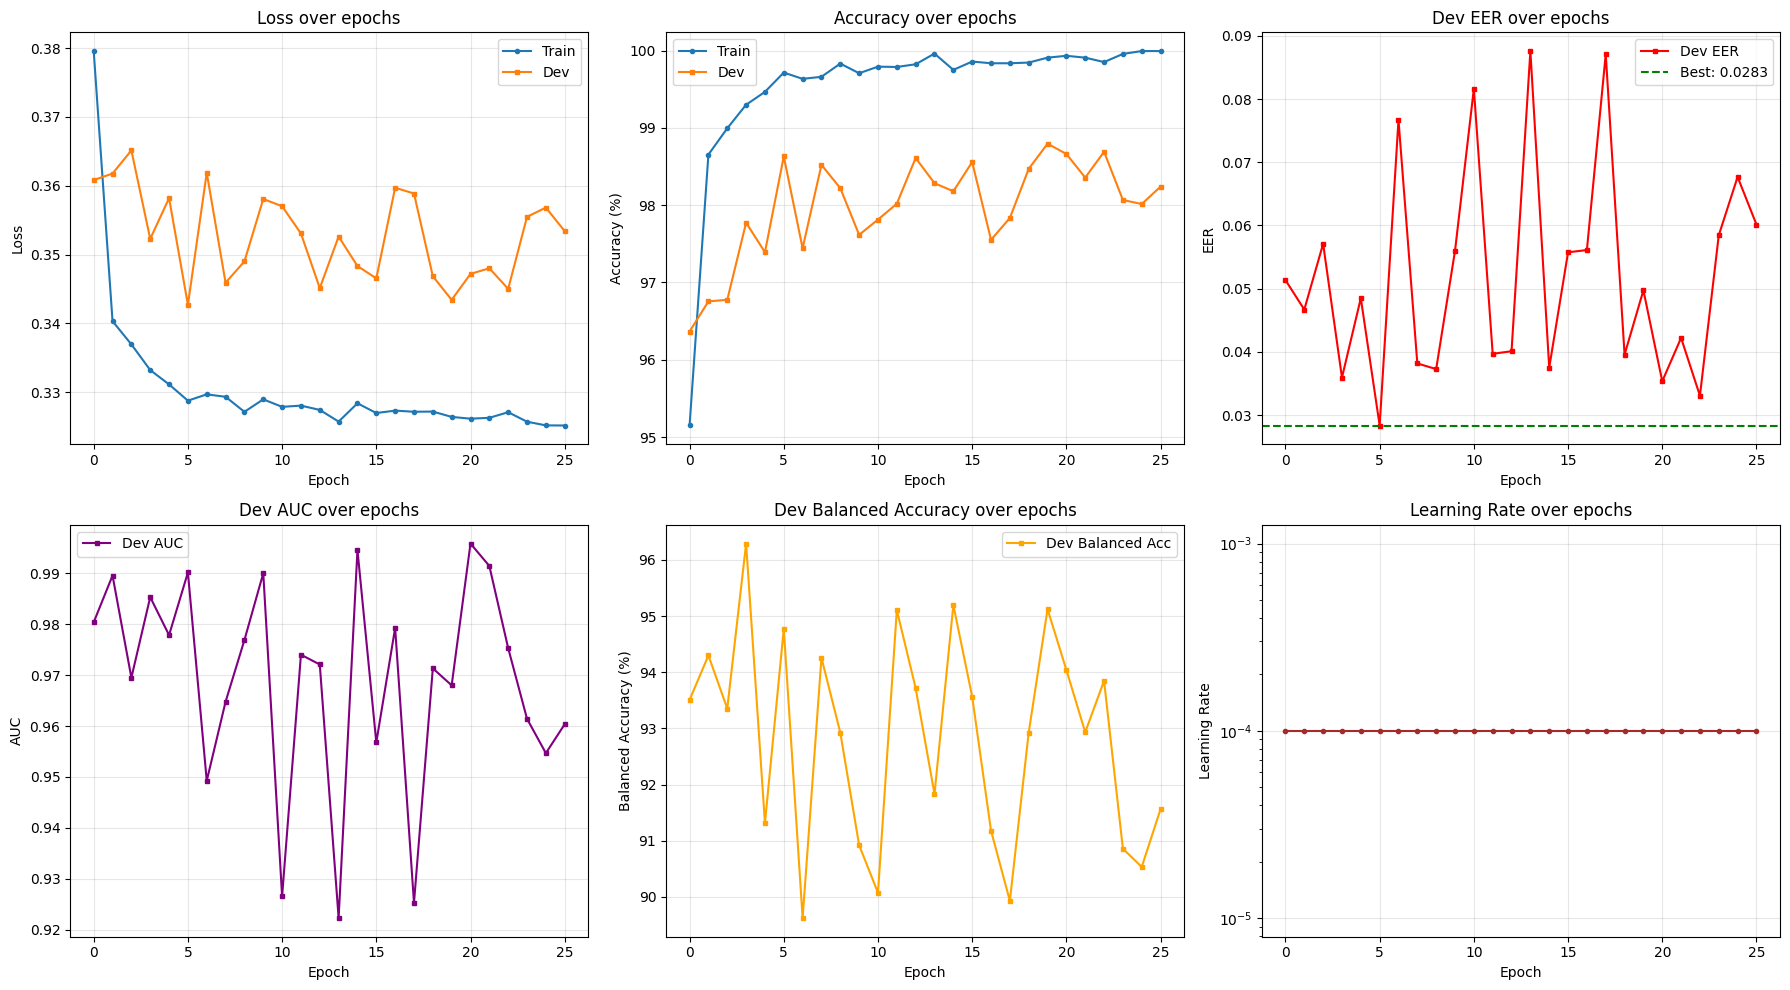

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', marker='o', markersize=3)
axes[0, 0].plot(history['dev_loss'], label='Dev', marker='s', markersize=3)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss over epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train', marker='o', markersize=3)
axes[0, 1].plot(history['dev_acc'], label='Dev', marker='s', markersize=3)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy over epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# EER
axes[0, 2].plot(history['dev_eer'], label='Dev EER', marker='s', markersize=3, color='red')
axes[0, 2].axhline(y=best_eer, color='green', linestyle='--', label=f'Best: {best_eer:.4f}')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('EER')
axes[0, 2].set_title('Dev EER over epochs')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(history['dev_auc'], label='Dev AUC', marker='s', markersize=3, color='purple')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].set_title('Dev AUC over epochs')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Balanced Accuracy
axes[1, 1].plot(history['dev_balanced_acc'], label='Dev Balanced Acc', marker='s', markersize=3, color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Balanced Accuracy (%)')
axes[1, 1].set_title('Dev Balanced Accuracy over epochs')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Learning Rate
axes[1, 2].plot(history['lr'], marker='o', markersize=3, color='brown')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Learning Rate')
axes[1, 2].set_title('Learning Rate over epochs')
axes[1, 2].set_yscale('log')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history2.png', dpi=150)
plt.show()

In [22]:
import json

with open("history2.json", "w") as f:
    json.dump(history, f, indent=4)

In [23]:
def simple_evaluate(model, data_loader, device, partition_name='Eval'):
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_probs = []
    all_sys_ids = []
    
    print(f"\nEvaluating {partition_name} set...")
    
    with torch.no_grad():
        for batch_x, batch_y, batch_meta in tqdm(data_loader, desc=partition_name):
            batch_x = batch_x.to(device)
            batch_out = model(batch_x)
            
            _, batch_pred = batch_out.max(dim=1)
            probs = torch.nn.functional.softmax(batch_out, dim=1)[:, 1]
            
            all_predictions.extend(batch_pred.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch_y.numpy())

            for meta in batch_meta:
                all_sys_ids.append(meta.sys_id)
    
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_sys_ids = np.array(all_sys_ids)
    
    overall_acc = (all_predictions == all_labels).mean() * 100

    fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=1)
    fnr = 1 - tpr
    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
    
    auc = roc_auc_score(all_labels, all_probs)
    
    balanced_acc = balanced_accuracy_score(all_labels, all_predictions) * 100
    
    print(f"\n{partition_name} Overall Accuracy: {overall_acc:.2f}%")
    print(f"EER: {eer:.4f} | AUC: {auc:.4f} | Balanced Accuracy: {balanced_acc:.2f}%")
    
    unique_sys_ids = np.unique(all_sys_ids)
    
    results = []
    
    for sys_id in unique_sys_ids:
        mask = all_sys_ids == sys_id
        
        labels_subset = all_labels[mask]
        preds_subset = all_predictions[mask]
        
        true_label = labels_subset[0]
        
        correct = (preds_subset == labels_subset).sum()
        total = len(labels_subset)
        detection_rate = correct / total
        
        if true_label == 1:
            attack_name = 'REAL'
        else:
            attack_name = data_loader.dataset.sysid_dict_inv[sys_id]
        
        results.append({
            'Attack': attack_name,
            'sys_id': sys_id,
            'Label': 'bonafide' if true_label == 1 else 'spoof',
            'Total': total,
            'Correct': correct,
            'Detection Rate': detection_rate,
        })
    
    df = pd.DataFrame(results)
    
    df['sort_key'] = df['Attack'].apply(lambda x: '0' if x == 'REAL' else x)
    df = df.sort_values('sort_key').drop('sort_key', axis=1)
    df = df.reset_index(drop=True)
    
    return df, overall_acc

In [24]:
def print_detection_table(df, partition_name='Eval'):
    print(f"{partition_name} SET - PER-ATTACK DETECTION RATES")
    
    print("\nDetailed Statistics:")
    print(df.to_string(index=False))
    
    
    attacks = df['Attack'].tolist()
    rates = df['Detection Rate'].tolist()
    
    header = " | ".join([f"{att:^6s}" for att in attacks])
    print(header)
    print("-" * len(header))
    
    values = " | ".join([f"{rate:^6.2f}" for rate in rates])
    print(values)
    
    print(f"\n{'='*80}")
    
    attack_df = df[df['Attack'] != 'REAL']
    if len(attack_df) > 0:
        print("\nSummary (attacks only):")
        print(f"  Mean:   {attack_df['Detection Rate'].mean():.4f}")
        print(f"  Median: {attack_df['Detection Rate'].median():.4f}")
        print(f"  Min:    {attack_df['Detection Rate'].min():.4f} ({attack_df.loc[attack_df['Detection Rate'].idxmin(), 'Attack']})")
        print(f"  Max:    {attack_df['Detection Rate'].max():.4f} ({attack_df.loc[attack_df['Detection Rate'].idxmax(), 'Attack']})")
    
    real_df = df[df['Attack'] == 'REAL']
    if len(real_df) > 0:
        print(f"\nBonafide (REAL) Detection: {real_df['Detection Rate'].values[0]:.4f}")

In [25]:
checkpoint = torch.load(CHECKPOINT_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1}")

# Evaluate Dev set
df_dev, acc_dev = simple_evaluate(model, dev_loader, DEVICE, 'Dev')
print_detection_table(df_dev, 'Dev')

# Evaluate Eval set
df_eval, acc_eval = simple_evaluate(model, eval_loader, DEVICE, 'Eval')
print_detection_table(df_eval, 'Eval')

# Save results
results_dir = Path('logs')
results_dir.mkdir(exist_ok=True)

df_dev.to_csv(results_dir / 'dev_per_attack.csv', index=False)
df_eval.to_csv(results_dir / 'eval_per_attack.csv', index=False)

print(f"\nResults saved to:")
print(f"  - {results_dir / 'dev_per_attack.csv'}")
print(f"  - {results_dir / 'eval_per_attack.csv'}")

Loaded model from epoch 6

Evaluating Dev set...


/tmp/ipykernel_7514/325065495.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH)


Dev:   0%|          | 0/195 [00:00<?, ?it/s]


Dev Overall Accuracy: 98.63%
EER: 0.0283 | AUC: 0.9902 | Balanced Accuracy: 94.77%
Dev SET - PER-ATTACK DETECTION RATES

Detailed Statistics:
Attack  sys_id    Label  Total  Correct  Detection Rate
  REAL       0 bonafide   2548     2291        0.899137
   A01       1    spoof   3716     3716        1.000000
   A02       2    spoof   3716     3713        0.999193
   A03       3    spoof   3716     3713        0.999193
   A04       4    spoof   3716     3715        0.999731
   A05       5    spoof   3716     3694        0.994080
   A06       6    spoof   3716     3662        0.985468
 REAL  |  A01   |  A02   |  A03   |  A04   |  A05   |  A06  
------------------------------------------------------------
 0.90  |  1.00  |  1.00  |  1.00  |  1.00  |  0.99  |  0.99 


Summary (attacks only):
  Mean:   0.9963
  Median: 0.9992
  Min:    0.9855 (A06)
  Max:    1.0000 (A01)

Bonafide (REAL) Detection: 0.8991

Evaluating Eval set...


Eval:   0%|          | 0/557 [00:00<?, ?it/s]


Eval Overall Accuracy: 88.89%
EER: 0.0868 | AUC: 0.9472 | Balanced Accuracy: 91.29%
Eval SET - PER-ATTACK DETECTION RATES

Detailed Statistics:
Attack  sys_id    Label  Total  Correct  Detection Rate
  REAL       0 bonafide   7355     6936        0.943032
   A07       1    spoof   4914     4914        1.000000
   A08       2    spoof   4914     4229        0.860602
   A09       3    spoof   4914     4914        1.000000
   A10       4    spoof   4914     4899        0.996947
   A11       5    spoof   4914     4904        0.997965
   A12       6    spoof   4914     4911        0.999389
   A13       7    spoof   4914     4914        1.000000
   A14       8    spoof   4914     4914        1.000000
   A15       9    spoof   4914     4906        0.998372
   A16      10    spoof   4914     4896        0.996337
   A17      11    spoof   4914     2921        0.594424
   A18      12    spoof   4914     1019        0.207367
   A19      13    spoof   4914     4047        0.823565
 REAL  |  A07  